<a href="https://colab.research.google.com/github/MrSanthosh3/santhosh-codebooster-2026/blob/main/Day2/Miniprojectday2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Successfully created 'students' table from 'student_performance.csv'.


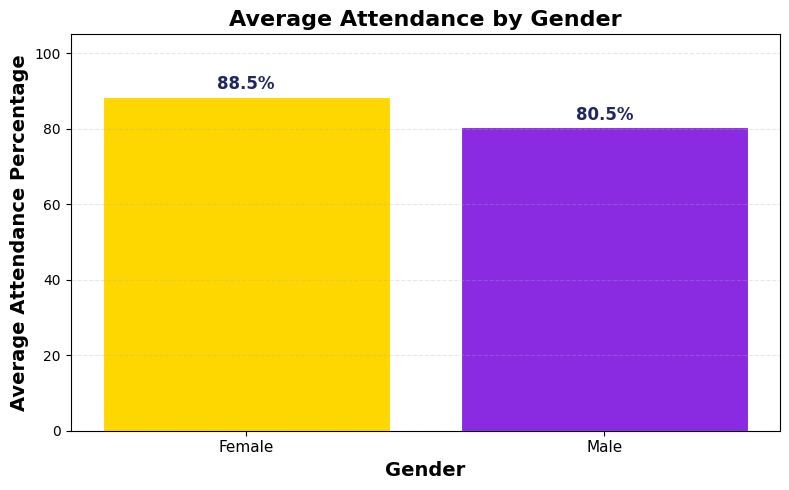

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('college.db')

# Load data from CSV and create the 'students' table if it doesn't exist
try:
    # Read the CSV file
    students_df = pd.read_csv('/content/student_performance.csv')
    # Write the DataFrame to a SQL table named 'students'
    students_df.to_sql('students', conn, if_exists='replace', index=False)
    print("Successfully created 'students' table from 'student_performance.csv'.")
except Exception as e:
    print(f"Error creating 'students' table: {e}")

chart2_sql = """
SELECT gender,
       ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC
"""

chart2_data = pd.read_sql_query(chart2_sql, conn)

fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = ["#FFD700", "#8A2BE2"]

bars = ax.bar(
    chart2_data["gender"],
    chart2_data["avg_attendance"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Attendance by Gender',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Gender',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'Average Attendance Percentage',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

conn.close()

In [5]:
conn = sqlite3.connect('college.db') # Re-establish connection

top_8_students_sql = """
SELECT name,
       (math_score + science_score + english_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

top_8_students_data = pd.read_sql_query(top_8_students_sql, conn)
print("Top 8 Students by Total Score:")
print(top_8_students_data)

conn.close() # Close connection after use

Top 8 Students by Total Score:
             name  total_score
0      Ananya Das          274
1     Tanvi Mehta          271
2  Akanksha Yadav          271
3     Divya Singh          263
4  Swati Kulkarni          262
5      Arjun Nair          261
6    Ritu Agarwal          256
7       Amit Bose          247


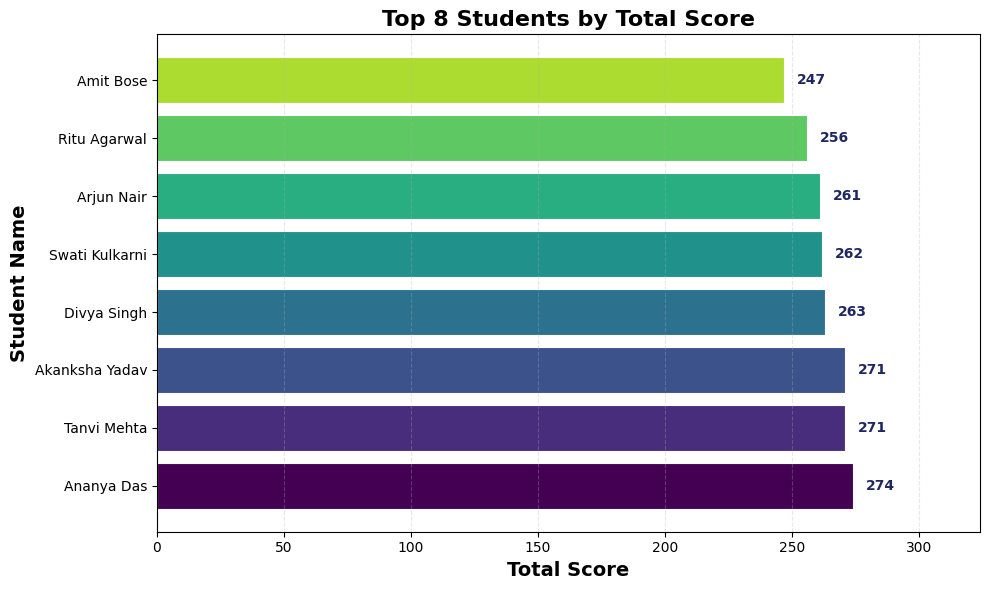